In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:

np.random.seed(42)

data = {
    'CustomerID': range(1, 11),
    'Age': np.random.randint(18, 70, 10),
    'Gender': np.random.choice(['Male', 'Female'], 10),
    'ServiceType': np.random.choice(['Fiber Optic', 'DSL', 'No Internet'], 10),
    'MonthlyCharges': np.round(np.random.uniform(20, 150, 10), 2),
    'DataUsageGB': np.round(np.random.uniform(10, 500, 10), 2),
    'ContractType': np.random.choice(['Month-to-month', 'One year', 'Two year'], 10),
    'TotalSpent': np.round(np.random.uniform(50, 5000, 10), 2),
    'Churn': np.random.choice([0, 1], 10, p=[0.7, 0.3])
}
telecom_df = pd.DataFrame(data)

print("Sample Telecom Dataset:")
display(telecom_df)

Sample Telecom Dataset:


,CustomerID,Age,Gender,ServiceType,MonthlyCharges,DataUsageGB,ContractType,TotalSpent,Churn
0,1,56,Male,DSL,57.86,32.76,Two year,2624.34,0
1,2,69,Male,DSL,99.54,307.70,Two year,2756.22,0
2,3,46,Female,DSL,38.13,93.56,Month-to-month,965.03,0
3,4,32,Male,DSL,57.98,41.88,Two year,4849.44,0
4,5,60,Female,Fiber Optic,67.63,474.95,Two year,3886.91,0
5,6,25,Female,Fiber Optic,79.29,483.16,One year,4700.52,1
6,7,38,Female,DSL,122.07,406.11,Month-to-month,4479.40,0
7,8,56,Male,DSL,45.96,159.26,One year,3009.60,0
8,9,36,Female,Fiber Optic,86.85,57.86,One year,4613.28,0
9,10,40,Male,Fiber Optic,97.01,345.27,One year,488.04,0


In [10]:
#converting gender to 0&1
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
telecom_df['Gender'] = label_encoder.fit_transform(telecom_df['Gender'])
display(telecom_df)

,CustomerID,Age,Gender,ServiceType,MonthlyCharges,DataUsageGB,ContractType,TotalSpent,Churn
0,1,56,1,DSL,57.86,32.76,Two year,2624.34,0
1,2,69,1,DSL,99.54,307.70,Two year,2756.22,0
2,3,46,0,DSL,38.13,93.56,Month-to-month,965.03,0
3,4,32,1,DSL,57.98,41.88,Two year,4849.44,0
4,5,60,0,Fiber Optic,67.63,474.95,Two year,3886.91,0
5,6,25,0,Fiber Optic,79.29,483.16,One year,4700.52,1
6,7,38,0,DSL,122.07,406.11,Month-to-month,4479.40,0
7,8,56,1,DSL,45.96,159.26,One year,3009.60,0
8,9,36,0,Fiber Optic,86.85,57.86,One year,4613.28,0
9,10,40,1,Fiber Optic,97.01,345.27,One year,488.04,0


In [11]:
print(telecom_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      10 non-null     int64  
 1   Age             10 non-null     int64  
 2   Gender          10 non-null     int64  
 3   ServiceType     10 non-null     object 
 4   MonthlyCharges  10 non-null     float64
 5   DataUsageGB     10 non-null     float64
 6   ContractType    10 non-null     object 
 7   TotalSpent      10 non-null     float64
 8   Churn           10 non-null     int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 852.0+ bytes
None


In [12]:
display(telecom_df.describe())

,CustomerID,Age,Gender,MonthlyCharges,DataUsageGB,TotalSpent,Churn
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,45.800000,0.500000,75.232000,240.251000,3237.278000,0.100000
std,3.02765,13.990473,0.527046,26.459656,182.855075,1562.717767,0.316228
min,1.00000,25.000000,0.000000,38.130000,32.760000,488.040000,0.000000
25%,3.25000,36.500000,0.000000,57.890000,66.785000,2657.310000,0.000000
50%,5.50000,43.000000,0.500000,73.460000,233.480000,3448.255000,0.000000
75%,7.75000,56.000000,1.000000,94.470000,390.900000,4579.810000,0.000000
max,10.00000,69.000000,1.000000,122.070000,483.160000,4849.440000,1.000000


In [14]:
#internet speed
internet=telecom_df.groupby('ServiceType')['DataUsageGB'].mean().reset_index()
display(internet)

,ServiceType,DataUsageGB
0,DSL,173.545
1,Fiber Optic,340.310


In [15]:
#payment failure
payment_failure=telecom_df.groupby('Churn')['TotalSpent'].mean().reset_index()
display(payment_failure)

,Churn,TotalSpent
0,0,3074.695556
1,1,4700.520000


In [16]:
#Deliver charges
deliver_charges=telecom_df.groupby('ContractType')['MonthlyCharges'].mean().reset_index()
display(deliver_charges)

,ContractType,MonthlyCharges
0,Month-to-month,80.1000
1,One year,77.2775
2,Two year,70.7525


In [17]:
#purchase completed
purchase_completed=telecom_df.groupby('Churn')['TotalSpent'].sum().reset_index()
display(purchase_completed)

,Churn,TotalSpent
0,0,27672.26
1,1,4700.52


In [18]:
#Total Abonded
total_abandoned=telecom_df.groupby('Churn')['TotalSpent'].count().reset_index()
display(total_abandoned)

,Churn,TotalSpent
0,0,9
1,1,1


In [20]:
#intenet diagnosis
internet=telecom_df.groupby('ServiceType')['Churn'].mean().reset_index()
display(internet)

,ServiceType,Churn
0,DSL,0.00
1,Fiber Optic,0.25


In [27]:
#payment diagnosis
payment=telecom_df.groupby('Churn')['MonthlyCharges'].mean().reset_index()
display(payment)

,Churn,MonthlyCharges
0,0,74.781111
1,1,79.290000


In [23]:
#delivery Diagnosis
delivery=telecom_df.groupby('ContractType')['MonthlyCharges'].mean().reset_index()
display(delivery)

,ContractType,MonthlyCharges
0,Month-to-month,80.1000
1,One year,77.2775
2,Two year,70.7525


In [26]:
#find route cause
root_cause=telecom_df.groupby('Churn')['ServiceType'].value_counts().reset_index(name='Count')
display(root_cause)

,Churn,ServiceType,Count
0,0,DSL,6
1,0,Fiber Optic,3
2,1,Fiber Optic,1


In [30]:
#maximum customers
maximum_customers=telecom_df.groupby('ServiceType')['CustomerID'].count().reset_index()
display(maximum_customers)

,ServiceType,CustomerID
0,DSL,6
1,Fiber Optic,4


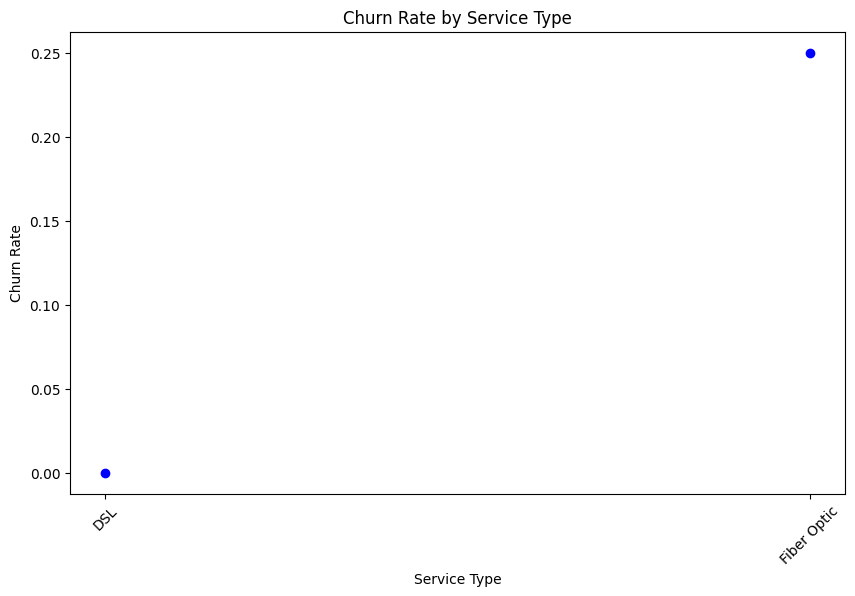

In [29]:
#visualization
plt.figure(figsize=(10, 6))
plt.scatter(internet['ServiceType'], internet['Churn'], color='blue')
plt.xlabel('Service Type')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Service Type')
plt.xticks(rotation=45)
plt.show()

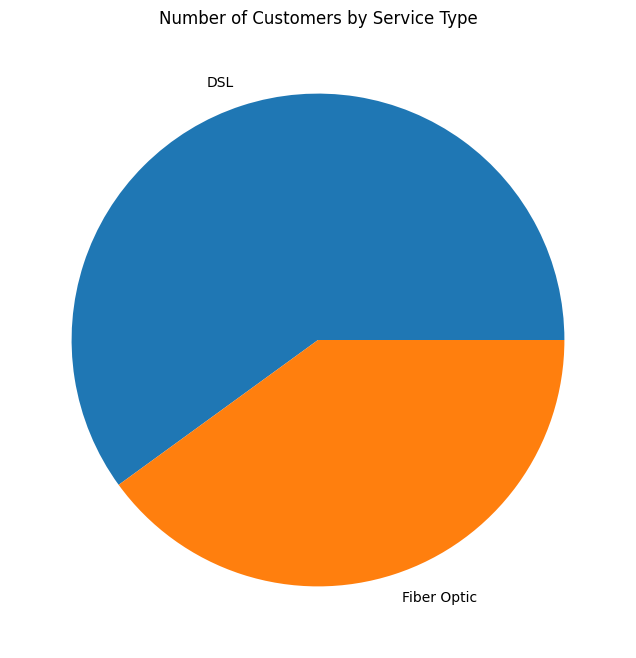

In [32]:
#ploting using pie chart for number of customers in company
plt.figure(figsize=(8, 8))
service_counts = telecom_df['ServiceType'].value_counts()
plt.pie(service_counts, labels=service_counts.index)
plt.title('Number of Customers by Service Type')
plt.ylabel('')
plt.show()